In [ ]:
Param_WorkspaceId = ""
Param_SemanticModelId= ""

StatementMeta(, 666c9701-6b83-473e-bc3c-403651493afe, 153, Finished, Available, Finished, False)

StatementMeta(, 666c9701-6b83-473e-bc3c-403651493afe, 159, Finished, Available, Finished, False)


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


,Table Name,Description,Hidden,Data Category,Type,Column,MetadataType,Semantic Model Id,Workspace Id,Measure Name,Expression,Measure Data Type,Measure Hidden,Measure Display Folder,Measure Description,Format String,Detail Rows Definition,Format String Definition,Measure Dependencies,Measure Type,Multiplicity,From Table,From Column,To Table,To Column,Active,Cross Filtering Behavior,Security Filtering Behavior,Join On Date Behavior,Rely On Referential Integrity,State,Modified Time,Relationship Name
0,SalesLT Customer,,False,,Table,CustomerID,Table/Column,5613d12a-a074-45d3-aa57-b7493861d796,d2776184-f5ee-462d-8cf2-0da38898f998,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN
1,SalesLT Customer,,False,,Table,NameStyle,Table/Column,5613d12a-a074-45d3-aa57-b7493861d796,d2776184-f5ee-462d-8cf2-0da38898f998,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN
2,SalesLT Customer,,False,,Table,Title,Table/Column,5613d12a-a074-45d3-aa57-b7493861d796,d2776184-f5ee-462d-8cf2-0da38898f998,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN
3,SalesLT Customer,,False,,Table,FirstName,Table/Column,5613d12a-a074-45d3-aa57-b7493861d796,d2776184-f5ee-462d-8cf2-0da38898f998,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN
4,SalesLT Customer,,False,,Table,MiddleName,Table/Column,5613d12a-a074-45d3-aa57-b7493861d796,d2776184-f5ee-462d-8cf2-0da38898f998,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN
5,SalesLT Customer,,False,,Table,LastName,Table/Column,5613d12a-a074-45d3-aa57-b7493861d796,d2776184-f5ee-462d-8cf2-0da38898f998,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN
6,SalesLT Customer,,False,,Table,Suffix,Table/Column,5613d12a-a074-45d3-aa57-b7493861d796,d2776184-f5ee-462d-8cf2-0da38898f998,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN
7,SalesLT Customer,,False,,Table,CompanyName,Table/Column,5613d12a-a074-45d3-aa57-b7493861d796,d2776184-f5ee-462d-8cf2-0da38898f998,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN
8,SalesLT Customer,,False,,Table,SalesPerson,Table/Column,5613d12a-a074-45d3-aa57-b7493861d796,d2776184-f5ee-462d-8cf2-0da38898f998,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN
9,SalesLT Customer,,False,,Table,EmailAddress,Table/Column,5613d12a-a074-45d3-aa57-b7493861d796,d2776184-f5ee-462d-8cf2-0da38898f998,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN


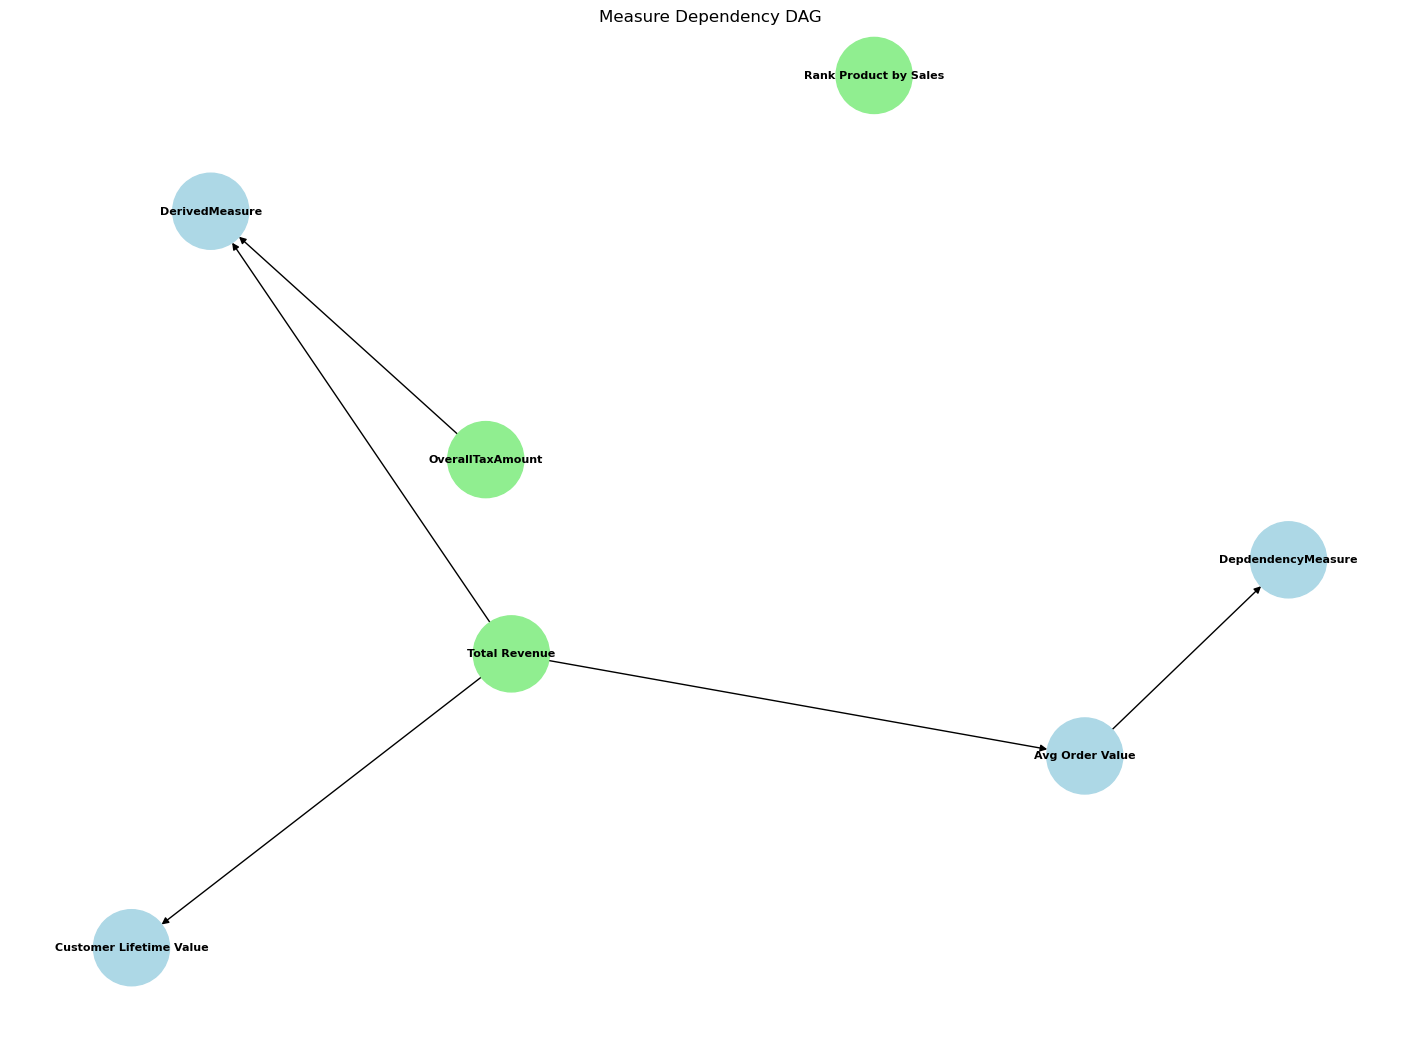

In [ ]:
import pandas as pd
import sempy.fabric as fabric
import networkx as nx
import matplotlib.pyplot as plt
import time

#%pip install openai (Use Environment)

from openai import AzureOpenAI
from notebookutils import mssparkutils as notebookutils


# AZURE OPENAI CONFIG

deployment_name = "gpt-4o-Hackathon"

endpoint = "https://<<OpenAIName>>.openai.azure.com/"
kvname = "<<KVName>>"
kvsecretname = "AzureOpenAIAPIKey"
kvurl = f"https://{kvname}.vault.azure.net/"

api_key = notebookutils.credentials.getSecret(kvurl, kvsecretname)

client = AzureOpenAI(
    azure_endpoint=endpoint,
    api_key=api_key,
    api_version="2025-01-01-preview"
)



def get_measure_description(dax_expression):

    if pd.isna(dax_expression) or not str(dax_expression).strip():
        return None

    try:
        prompt = f"""
        Explain the following DAX measure in simple business terms (2-3 lines):

        DAX:
        {dax_expression}
        """

        response = client.chat.completions.create(
            model=deployment_name,
            messages=[
                {"role": "system", "content": "You are a Data Governance assistant explaining DAX measures."},
                {"role": "user", "content": prompt}
            ],
            temperature=0.2
        )

        return response.choices[0].message.content.strip()

    except Exception as e:
        return f"Error: {e}"



metadata = []


# Tables & Columns

try:
    df_tables = fabric.list_tables(
        dataset=Param_SemanticModelId,
        workspace=Param_WorkspaceId,
        include_columns=True
    )

    df_tables = df_tables.rename(columns={'Name': 'Table Name'})

    df_tables = df_tables.assign(
        MetadataType='Table/Column',
        **{
            'Semantic Model Id': Param_SemanticModelId,
            'Workspace Id': Param_WorkspaceId
        }
    )

    metadata.append(df_tables)

except Exception as e:
    print(f"Warning (Tables): {e}")



# Measures + Dependencies + AI

try:
    df_measures = fabric.list_measures(
        dataset=Param_SemanticModelId,
        workspace=Param_WorkspaceId
    )

    df_measures = df_measures.rename(
        columns={
            'Measure Name': 'Measure Name',
            'Measure Expression': 'Expression'
        }
    )



    all_measures = df_measures['Measure Name'].tolist()

    def extract_dependencies(expression):
        if pd.isna(expression):
            return []
        return [m for m in all_measures if f'[{m}]' in str(expression)]

    df_measures['Measure Dependencies'] = df_measures['Expression'].apply(extract_dependencies)

    df_measures['Measure Type'] = df_measures['Measure Dependencies'].apply(
        lambda x: 'Base Measure' if len(x) == 0 else 'Derived Measure'
    )


    df_measures['Measure Description'] = df_measures['Expression'].apply(get_measure_description)

    time.sleep(0.1)

    df_measures = df_measures.assign(
        MetadataType='Measure',
        **{
            'Semantic Model Id': Param_SemanticModelId,
            'Workspace Id': Param_WorkspaceId
        }
    )

    metadata.append(df_measures)

except Exception as e:
    print(f"Warning (Measures): {e}")



# Relationships

try:
    df_relationships = fabric.list_relationships(
        dataset=Param_SemanticModelId,
        workspace=Param_WorkspaceId
    )

    df_relationships = df_relationships.assign(
        MetadataType='Relationship',
        **{
            'Semantic Model Id': Param_SemanticModelId,
            'Workspace Id': Param_WorkspaceId
        }
    )

    metadata.append(df_relationships)

except Exception as e:
    print(f"Warning (Relationships): {e}")



# CONSOLIDATED METADATA

if metadata:
    df_metadata = pd.concat(metadata, ignore_index=True)

    pd.set_option('display.max_rows', None)
    pd.set_option('display.max_columns', None)
    pd.set_option('display.max_colwidth', None)
    pd.set_option('display.width', None)
    display(df_metadata)
else:
    print("No metadata extracted.")



# MEASURE DEPENDENCY DAG

try:
    G = nx.DiGraph()
    node_colors = {}

    for _, row in df_measures.iterrows():
        measure = row['Measure Name']
        dependencies = row['Measure Dependencies']

        G.add_node(measure)
        node_colors[measure] = 'lightgreen' if len(dependencies) == 0 else 'lightblue'

        for dep in dependencies:
            G.add_edge(dep, measure)

            if dep not in node_colors:
                node_colors[dep] = 'lightgreen'





    # Plot DAG

    plt.figure(figsize=(14, 10))
    pos = nx.spring_layout(G, k=0.6, seed=42)

    nx.draw(
        G, pos,
        with_labels=True,
        node_color=[node_colors[node] for node in G.nodes()],
        node_size=3000,
        font_size=8,
        font_weight='bold',
        arrows=True
    )

    plt.title("Measure Dependency DAG")
    plt.axis('off')
    plt.show()

except Exception as e:
    print(f"Warning (DAG): {e}")